**Lab 3: Building Custom Datasets**

While ImageFolder is convenient, sometimes you need more control over how data is loaded. In this lab, we'll learn how to build a custom Dataset class from scratch by subclassing torch.utils.data.Dataset.

Project Overview: PyTorch Custom Datasets

![image](https://raw.githubusercontent.com/poridhiEng/lab-asset/c05b0fcffc73075ac57eef168b7647e050b9156b/tensorcode/Deep-learning-with-pytorch/Custom-Datasets-with-pytorch/Lab_01/images/lab1.svg)

This project is split into

4 labs

:

Lab 1: Data Preparation & Exploration

— Download and visualize custom data

Lab 2: ImageFolder & DataLoaders

— Transform and load images efficiently

(Current Lab) Lab 3: Custom Datasets

— Build your own Dataset class from scratch

Lab 4: TinyVGG Model Training

— Create and train a CNN model

**Goal of This Lab**

In this lab, we focus on building a custom **Dataset class** that replicates the functionality of **ImageFolder**.

### What we’ll learn:

* When and why to create custom datasets
* The required methods for a PyTorch Dataset
* How the Dataset interacts with the DataLoader
* The complete data flow from files to training batches



### Part 1: Why Custom Datasets?

#### The Limitations of Built-in Datasets

PyTorch provides convenient built-in datasets like **ImageFolder** that work well for standard image classification tasks. However, real-world data rarely comes in a perfect format. You might have:

* Images with labels stored in a separate CSV file
* Medical images with complex metadata in JSON format
* Multi-modal data combining images, text, and tabular data
* Data that needs to be fetched from a database on-the-fly
* Custom file formats or naming conventions

In these scenarios, built-in datasets simply cannot accommodate your needs. This is where custom datasets become essential.

#### The Trade-offs

| Pros                                    | Cons                               |
| --------------------------------------- | ---------------------------------- |
| Complete control over data loading      | More code to write and maintain    |
| Handle any data format or structure     | Potential for bugs if not careful  |
| Custom preprocessing at load time       | May be slower if not optimized     |
| Deep understanding of PyTorch internals | Need to handle edge cases yourself |

#### When to Choose Custom Datasets

Use a custom Dataset when:

* Your data isn't organized in the standard folder-per-class structure
* You need custom preprocessing logic that transforms can't handle
* You want to combine multiple data sources into a single sample
* You're working with non-image data (audio, video, text, point clouds)
* You need lazy loading from databases or remote storage
* You want to understand how PyTorch data loading actually works

---

### Part 2: Understanding the Dataset Contract

#### What PyTorch Expects from a Dataset

When you create a custom Dataset in PyTorch, you're essentially making a promise to the framework. PyTorch's DataLoader needs to know two things about your data:

* How many samples exist? → So it knows when an epoch is complete
* How to get a specific sample? → So it can fetch individual data points

This is formalized through Python's special methods (also called "dunder" or "magic" methods).

#### The Three Essential Methods

Every PyTorch Dataset must implement three methods:

✔️ `__init__()` → Initialize dataset (load file paths, labels, etc.)

✔️ `__len__()` → Return total number of samples

✔️ `__getitem__()` → Return a single sample given an index






### 🔹 PyTorch কী জানতে চায়?

যখন তুমি custom Dataset বানাও, PyTorch (বিশেষ করে DataLoader) তোমার Dataset থেকে ২টা জিনিস জানতে চায়:

---

### 1. **How many samples exist?**

👉 ডাটাসেটে মোট কতগুলো sample আছে?

কেন দরকার?

* এক epoch কখন শেষ হবে তা বুঝতে
* batching ঠিকভাবে করতে

এটা সাধারণত করা হয় `__len__()` method দিয়ে।

---

### 2. **How to get a specific sample?**

👉 নির্দিষ্ট index দিলে সেই sample কীভাবে পাওয়া যাবে?

যেমন:

```python
dataset[5]
```

এটা কী return করবে?
👉 একটা image + label

এটা করা হয় `__getitem__(index)` method দিয়ে।

---


### 🔹 Dunder / Magic Methods কী?

এগুলো হলো Python এর special methods যেগুলো `__` দিয়ে শুরু ও শেষ হয়:

* `__init__` → dataset setup
* `__len__` → dataset size
* `__getitem__` → index দিয়ে data আনা

👉 এগুলোকে “magic” বলা হয় কারণ Python নিজে এগুলো automatically call করে।



Every PyTorch Dataset must implement three methods:
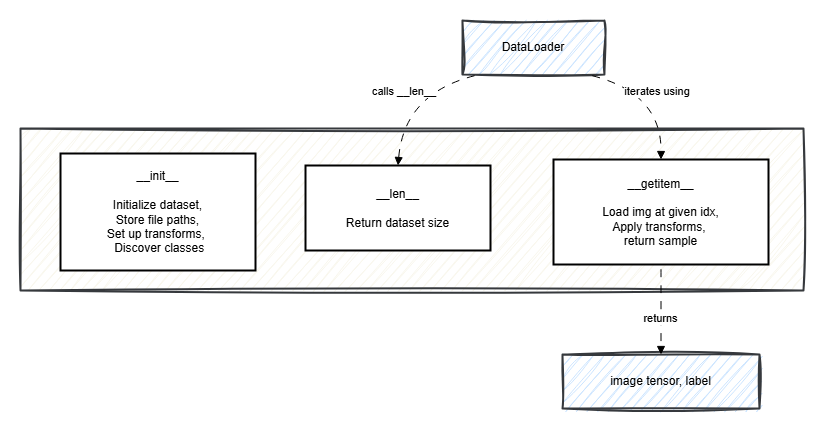

### 1. The Initialization Method (`__init__`)

This is where you set up everything your dataset needs to function. Think of it as the "preparation phase" before any data is actually loaded:

* Store file paths: Collect all the paths to your data files
* Set up transforms: Keep a reference to any image transformations
* Create label mappings: Build a dictionary that maps class names to numbers
* Load metadata: If you have annotations in a file, load them here

The key insight is that `__init__` doesn't load the actual data—it only prepares the infrastructure for loading data later. This is called **lazy loading** and is crucial for memory efficiency with large datasets.

---

### 2. The Length Method (`__len__`)

This method answers the question: *"How many samples are in this dataset?"*

The DataLoader calls this method to:

* Determine how many batches make up one epoch
* Validate that requested indices are within bounds
* Enable the Python `len()` function on your dataset

For image classification, this typically returns the count of image files. For other tasks, it might be the number of rows in a CSV or entries in a database.

---

### 3. The Get Item Method (`__getitem__`)

This is the heart of your custom dataset. When PyTorch needs a specific sample, it calls this method with an index and expects to receive that sample.

The method must:

* Locate the data using the provided index
* Load the data from disk, database, or memory
* Apply transformations if any are specified
* Extract the label for that specific sample
* Return a tuple of `(data, label)`

This method is called repeatedly during training—once for each sample in each batch, for every epoch. Efficiency here directly impacts training speed.

---




## 🔹 1. `__init__()` — Initialization (Setup phase)

👉 এটা dataset এর শুরুতে run হয়
👉 এখানে actual data load করা হয় না, শুধু প্রস্তুতি নেওয়া হয়

তুমি এখানে যা করো:

* file paths collect করা
* transforms সেট করা
* class → index mapping তৈরি করা
* metadata (CSV/JSON) load করা

✅ মূল ধারণা:
`__init__` শুধু setup করে, data load করে না → এটাকে বলে **lazy loading**

👉 এতে memory বাঁচে, especially বড় dataset এর ক্ষেত্রে।

---

## 🔹 2. `__len__()` — Dataset size

👉 এই method বলে দেয় dataset এ মোট কয়টা sample আছে

PyTorch এটা ব্যবহার করে:

* epoch কত batch হবে তা নির্ধারণ করতে
* index valid কিনা check করতে
* `len(dataset)` কাজ করার জন্য

👉 Example:

* image dataset হলে → total image count
* CSV হলে → row count

---

## 🔹 3. `__getitem__(index)` — Data fetch

👉 এটা dataset এর সবচেয়ে important অংশ

যখন তুমি বলো:

```python id="getitem1"
dataset[5]
```

তখন এই method run হয়।

এটা যা করে:

* index অনুযায়ী data locate করে
* disk/database থেকে data load করে
* transform apply করে
* label extract করে
* return করে → `(data, label)`

---

### 🔁 Training এ কীভাবে use হয়?

* DataLoader বারবার `__getitem__` call করে
* প্রতিটা batch বানানোর জন্য
* প্রতিটা epoch এ multiple times call হয়

👉 তাই এটা efficient হওয়া খুব গুরুত্বপূর্ণ (training speed এর জন্য)


### Part 3: The Data Flow Journey

#### How the DataLoader Orchestrates Everything

The **DataLoader** is the conductor of this orchestra. Here’s what happens during training:

* **Epoch begins:** DataLoader asks `__len__` for total samples
* **Create indices:** If shuffling, it randomly permutes indices `0` to `N-1`
* **Form batches:** Groups indices into chunks of `batch_size`
* **Fetch samples:** For each index in a batch, calls `__getitem__`
* **Collate:** Stacks individual samples into batch tensors
* **Deliver:** Provides the batch to your training loop

The beauty of this design is that your custom Dataset only needs to handle individual samples. The DataLoader handles all the complexity of batching, shuffling, and parallel loading.




## 🔹 DataLoader = “conductor”

👉 যেমন orchestra তে conductor সবাইকে coordinate করে, তেমনি DataLoader dataset থেকে data এনে training loop এ দেয়।

---

## 🔁 Step-by-step Data Flow

### 1. **Epoch begins**

👉 Training শুরু হলে DataLoader প্রথমে dataset এর size জানতে চায়:

* `__len__()` call করে
* জানতে পারে মোট কতগুলো sample আছে (N)

---

### 2. **Create indices**

👉 তারপর DataLoader indices তৈরি করে:

* Normal: `0 → N-1`
* If `shuffle=True`: indices random order এ permute হয়

Example:

```
[0,1,2,3,4] → [3,1,4,0,2]
```

👉 এতে model randomness পায় → better learning হয়

---

### 3. **Form batches**

👉 এরপর indices গুলো batch আকারে group করা হয়

Example:

```
batch_size = 2

[3,1,4,0,2] →

Batch 1: [3,1]
Batch 2: [4,0]
Batch 3: [2]
```

---

### 4. **Fetch samples**

👉 প্রতিটা batch এর index এর জন্য DataLoader `__getitem__()` call করে

Example:

```
dataset[3], dataset[1]
```

👉 প্রতিটা sample individually load হয়

---

### 5. **Collate**

👉 Individual samples গুলো একসাথে stack করে tensor বানানো হয়

Example:

* images → stack হয়ে batch tensor
* labels → list → tensor

👉 এই কাজটা করে collate function

---

### 6. **Deliver to training loop**

👉 Finally DataLoader একটা batch return করে:

```python
(images, labels)
```

👉 এগুলো model training এ ব্যবহার হয়

---

## 🎯 Key Insight

👉 তোমার custom Dataset শুধু এইটা handle করে:

* single sample load করা (`__getitem__`)

👉 DataLoader handle করে:

* batching
* shuffling
* parallel loading
* tensor stacking




### Part 4: Building a Class Discovery System

#### The Problem of Dynamic Labels

In image classification, we need to map folder names (like `"pizza"`, `"steak"`, `"sushi"`) to integer labels (0, 1, 2) that neural networks can process. But we don’t want to hardcode these mappings—what if someone adds a new class or uses the dataset with different categories?

---

#### The Solution: Automatic Class Discovery

A well-designed custom dataset discovers classes automatically by scanning the directory structure. This involves:

* Directory scanning: Look at all subdirectories in the data folder
* Alphabetical sorting: Ensure consistent ordering across runs
* Index assignment: Map each class name to a sequential integer
* Validation: Raise an error if no classes are found

This approach mirrors what **ImageFolder** does internally, making your custom dataset a true drop-in replacement.

---

#### Why Sorting Matters

Sorting class names alphabetically ensures that:

* The same dataset always produces the same class indices
* Different machines processing the same data get identical mappings
* Saved models remain compatible with the dataset

Without sorting, you might train a model where `"pizza" = 0`, but when you load that model on a different machine, `"pizza"` might become `1` due to filesystem ordering differences.


এই অংশটা বোঝাচ্ছে **কিভাবে custom Dataset automatically class (label) identify করে এবং কেন এটা important**। সহজভাবে বুঝাই:

---

## 🔹 The Problem of Dynamic Labels

Image classification এ neural network কাজ করে **numbers (0,1,2...)** দিয়ে, কিন্তু data থাকে **class name (pizza, steak, sushi)** আকারে।

👉 তাই আমাদের mapping দরকার:

```
pizza → 0  
steak → 1  
sushi → 2
```

❗ Problem:
এই mapping hardcode করলে flexible থাকে না।

* নতুন class add করলে সমস্যা
* dataset change হলে mapping mismatch হতে পারে

---

## 🔹 The Solution: Automatic Class Discovery

👉 Custom Dataset নিজেই folder structure দেখে class বের করে নেয়।

### কীভাবে কাজ করে:

### 1. Directory scanning

Dataset folder এর ভিতরে যত subfolder আছে সেগুলো detect করে:

```id="d5k9qz"
data/
  pizza/
  steak/
  sushi/
```

👉 এখানে class গুলো automatically:

* pizza
* steak
* sushi

---

### 2. Alphabetical sorting

👉 class নামগুলো alphabetically sort করা হয়:

```
pizza, sushi, steak → sort → pizza, steak, sushi
```

👉 এতে order consistent থাকে

---

### 3. Index assignment

👉 এরপর sequential number assign করা হয়:

```
pizza → 0  
steak → 1  
sushi → 2
```

👉 এই mapping dictionary বানানো হয়

---

### 4. Validation

👉 যদি কোনো class না পাওয়া যায় → error throw করা হয়
(মানে dataset empty বা wrong path)

---

## 🔹 Why Sorting Matters (গুরুত্ব)

Sorting না করলে problem হয়:

### ❌ Without sorting:

Filesystem যেভাবে read করে:

```
pizza → 0  
steak → 1  
```

অন্য machine এ:

```
steak → 0  
pizza → 1  
```

👉 mapping mismatch হয়ে যায়

---

### ✅ With sorting:

সব জায়গায় একই mapping থাকবে:

```
pizza → 0  
steak → 1  
sushi → 2  
```



### Part 5: Extracting Labels from File Paths

#### The Path-Based Label Strategy

In folder-structured datasets, the class label is embedded in the file path itself. For example:

```
data/train/pizza/image001.jpg
          ↑
     class name
```

When `__getitem__` needs to return a label, it must:

* Get the file path for the requested index
* Extract the parent folder name from that path
* Look up the corresponding integer in the class-to-index mapping

This is a common pattern in image classification datasets. However, your custom dataset could extract labels from:

* A CSV file with image names and labels
* JSON annotations alongside each image
* Filename patterns (e.g., `positive_001.jpg` vs `negative_001.jpg`)
* Database queries

The flexibility to define your own label extraction logic is one of the main reasons to use custom datasets.


এই অংশটা বোঝাচ্ছে **কিভাবে image এর label file path থেকেই বের করা হয়**। সহজভাবে step-by-step বুঝাই:

---

## 🔹 মূল ধারণা: Label path এর ভিতরেই থাকে

ধরো তোমার dataset এমন:

```
data/train/pizza/image001.jpg
```

👉 এখানে:

* `pizza` = class (label)

অর্থাৎ folder নামটাই label!

---

## 🔸 Path-Based Label Strategy কী?

👉 যখন `__getitem__(index)` call হয়, তখন dataset এই কাজগুলো করে:

### Step 1: File path নেয়

```python
path = "data/train/pizza/image001.jpg"
```

---

### Step 2: Parent folder বের করে

```python
label_name = "pizza"
```

👉 মানে folder name extract করা

---

### Step 3: Number এ convert করে

```python
class_to_idx = {
  "pizza": 0,
  "steak": 1
}
```

👉 তারপর:

```python
label = class_to_idx[label_name]  # 0
```

---

### ✔️ Final Output:

```python
(image, label)
```

---

## 🔹 কেন এটা popular?

👉 কারণ image classification dataset সাধারণত এভাবেই organized থাকে
👉 PyTorch এর ImageFolder ও এই logic use করে

---

## 🔸 Custom Dataset কেন useful?

কারণ তুমি label বের করার logic নিজে define করতে পারো 👇

---

### 🔹 Different ways to extract labels:

#### 1. CSV file থেকে

```csv
image001.jpg, pizza
```

---

#### 2. JSON file থেকে

```json
{
  "image001.jpg": "pizza"
}
```

---

#### 3. Filename থেকে

```text
positive_001.jpg → positive
negative_002.jpg → negative
```

---

#### 4. Database থেকে

👉 query করে label আনা



### Part 6: Transform Application Strategy

#### Training vs Testing Transforms

A critical concept in custom datasets is the difference between training and testing transforms:

| Phase    | Augmentation                  | Purpose                             |
| -------- | ----------------------------- | ----------------------------------- |
| Training | Yes (flips, rotations, crops) | Improve model generalization        |
| Testing  | No augmentation               | Consistent, reproducible evaluation |

---

#### Why This Distinction Matters

During training, we deliberately introduce variation through data augmentation. Random horizontal flips, color jittering, and random crops help the model learn invariant features. If a model can recognize a pizza whether it's flipped or not, it’s more robust.

During testing, we need consistent, reproducible results. If we applied random augmentations to test images, our evaluation metrics would vary between runs, making it impossible to compare models fairly.

---

#### The Transform Pipeline

When a sample is requested via `__getitem__`, the typical flow is:

* Load raw image from disk using PIL or similar
* Check for transforms — if none provided, return raw image
* Apply transform chain — resize, augment, convert to tensor
* Return transformed result — ready for the neural network

The transforms are typically composed using `transforms.Compose()`, which chains multiple operations into a single callable.


এই অংশটা **transform (image preprocessing)** নিয়ে—বিশেষ করে training আর testing এর সময় কীভাবে আলাদা ভাবে ব্যবহার করতে হয়। একদম সহজভাবে লাইন ধরে বুঝাই:

---

## 🔹 Training vs Testing Transforms

### 👉 Training phase

* ✔️ Augmentation থাকে (flip, rotate, crop)
* 🎯 Goal: model কে আরও **robust** করা

📌 Example:
pizza image উল্টা হলেও model যেন চিনতে পারে

---

### 👉 Testing phase

* ❌ কোন augmentation থাকে না
* 🎯 Goal: **consistent result**

📌 কারণ:

* random transform দিলে result change হবে
* model comparison করা যাবে না

---

## 🔸 Why This Distinction Matters

### 🔹 Training এ কেন augmentation?

👉 model কে বিভিন্ন variation দেখানো হয়:

* horizontal flip
* random crop
* color change

👉 এতে model generalize করতে শেখে
(মানে নতুন data তেও ভালো perform করে)

---

### 🔹 Testing এ কেন না?

👉 testing এ same input → same output দরকার

❌ যদি random augmentation দাও:

* accuracy প্রতিবার বদলাবে
* fair comparison হবে না

---

## 🔹 Transform Pipeline (flow)

যখন `__getitem__` call হয়, তখন এই step গুলো হয়:

---

### 1️⃣ Load raw image

```python
image = Image.open(path)
```

👉 disk থেকে image আনা হয়

---

### 2️⃣ Check transforms

👉 transform দেওয়া আছে কিনা check করা হয়

* না থাকলে raw image return

---

### 3️⃣ Apply transforms

👉 একের পর এক processing করা হয়:

* resize
* augmentation
* tensor conversion

---

### 4️⃣ Return final output

```python
return image, label
```

👉 এখন image model এ দেওয়ার জন্য ready

---

## 🔹 transforms.Compose() কী?

👉 এটা multiple transform একসাথে chain করে:

```python
transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
```



### Part 7: Verifying Your Implementation

#### The Comparison Test

After building a custom dataset, you should verify it works correctly by comparing against a known-good implementation. For image folder datasets, **ImageFolder** serves as the reference:

| Property to Check      | Why It Matters                      |
| ---------------------- | ----------------------------------- |
| Number of samples      | Ensures all files were found        |
| Class names            | Confirms correct folder scanning    |
| Class-to-index mapping | Validates consistent label encoding |
| Sample shape           | Verifies transforms work correctly  |
| Sample type            | Confirms proper tensor conversion   |

---

#### Debugging Common Issues

* **Wrong number of samples:**
  Check your glob pattern—are you matching all image types? `.jpg` won’t match `.png` files.

* **Incorrect class order:**
  Ensure you're sorting class names consistently. Different sorting (or no sorting) leads to different label assignments.

* **Transform errors:**
  Some transforms expect PIL images, others expect tensors. Check the order of your transform chain.

* **Memory issues:**
  If `__init__` loads all images into memory, large datasets will crash. Only store paths in `__init__`; load images in `__getitem__`.

---

### Key Takeaways

| Concept              | Description                                                       |
| -------------------- | ----------------------------------------------------------------- |
| Dataset base class   | Inherit from `torch.utils.data.Dataset` to create custom datasets |
| `__init__`           | Prepare paths, transforms, and class mappings (don't load data)   |
| `__len__`            | Return total sample count for DataLoader to manage epochs         |
| `__getitem__`        | Load and return individual samples on demand                      |
| Class discovery      | Automatically find classes from folder structure                  |
| Label extraction     | Convert class names to integers via dictionary lookup             |
| Transform separation | Use augmentation for training, not testing                        |

---

If you want, I can now combine all Parts (1–7) into a **single clean PDF-style note** or convert this into **PyTorch code implementation** 👍


এই অংশটা বোঝাচ্ছে **তুমি যে custom Dataset বানিয়েছো সেটা ঠিকমতো কাজ করছে কিনা কীভাবে যাচাই (verify) করবে**। সহজভাবে বুঝাই:

---

## 🔹 The Comparison Test (মিলিয়ে দেখা)

👉 তুমি তোমার custom dataset কে একটা **trusted dataset (ImageFolder)** এর সাথে compare করবে।

🎯 Goal:
তোমার dataset ঠিকভাবে কাজ করছে কিনা check করা

---

## 🔸 কী কী check করতে হবে?

### 1. **Number of samples**

👉 মোট কয়টা image detect হয়েছে

✔️ কেন গুরুত্বপূর্ণ?
সব file ঠিকমতো load হয়েছে কিনা বুঝতে

---

### 2. **Class names**

👉 কোন কোন class detect হয়েছে

✔️ check:

* সব folder read হয়েছে?
* কোনো class miss হয়েছে?

---

### 3. **Class-to-index mapping**

👉 class → number mapping ঠিক আছে কিনা

✔️ example:

```python
pizza → 0  
steak → 1
```

👉 mismatch হলে training ভুল হবে

---

### 4. **Sample shape**

👉 image এর shape ঠিক আছে কিনা

✔️ example:

```python
[3, 224, 224]
```

👉 transform ঠিকমতো apply হয়েছে কিনা বোঝা যায়

---

### 5. **Sample type**

👉 data type ঠিক আছে কিনা

✔️ image → tensor হয়েছে?
✔️ label → integer হয়েছে?

---

## 🔹 Debugging Common Issues

### ❌ 1. Wrong number of samples

👉 Problem:

* `.jpg` file নিচ্ছে কিন্তু `.png` নিচ্ছে না

✔️ Solution:

* glob pattern ঠিক করো
* সব file type include করো

---

### ❌ 2. Incorrect class order

👉 Problem:

* class sorting ঠিক না

✔️ Solution:

* সবসময় alphabetical sorting use করো

---

### ❌ 3. Transform errors

👉 Problem:

* কিছু transform PIL image চায়
* কিছু tensor চায়

✔️ Solution:

* transform order ঠিক রাখো

Example:

```python
Resize → ToTensor (✔️)
ToTensor → Resize (❌)
```

---

### ❌ 4. Memory issues

👉 Problem:

* `__init__` এ সব image load করলে RAM শেষ হয়ে যাবে

✔️ Solution:

* `__init__` → শুধু path store করো
* `__getitem__` → image load করো





### Setting Up the Environment

Now we will set up the environment for this lab, then run the notebook to practice building your custom dataset.

#### Step 1: Install Jupyter Extension

Open VS Code Server provided by Poridhi, go to **Extensions** (`Ctrl + Shift + X`), and install the **Jupyter extension**.


![image](https://raw.githubusercontent.com/poridhiEng/lab-asset/c86bc88e676d50722669abf52c9c25213adc5b70/tensorcode/Deep-learning-with-pytorch/Classification/Lab_01/images/image-2.png)

Step 2: Create Virtual Environment

In [ ]:
sudo apt install python3.12-venv
python3 -m venv venv
source venv/bin/activate

Step 3: Download the Notebook

In [3]:
!curl -O https://raw.githubusercontent.com/poridhioss/Introduction-to-Deep-Learning-with-Pytorch-Resources/refs/heads/main/Custom-Datasets/lab_03.ipynb


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 18701  100 18701    0     0    99k      0 --:--:-- --:--:-- --:--:--   98k


It will download the notebook to your current directory from

Poridhi's GitHub repository

.

Step 4: Open and Run the Notebook

Open

lab_03.ipynb

in VS Code. In the top right corner of the notebook, you will see a button

Select Kernel

. Click on it, then a popup will open to select

Python Environment

. After selecting the Python environment for the first time, it will ask permission to install

python ipykernel

. Click on

Install

button to install the

python ipykernel

. Once installed, you will see the

venv

virtual environment in the list of kernels. Select it as the kernel.

![image](https://github.com/poridhiEng/lab-asset/blob/main/tensorcode/Deep-learning-with-pytorch/Classification/Lab_01/images/image-3.png?raw=true)

Next Steps

In

Lab 4

, we'll build and train a TinyVGG CNN model on our custom dataset!